# Modulo 2 · Tema 2 — Imputacion Avanzada de Valores Faltantes
## Diplomado: Machine Learning en Seguros · FC UNAM · 2026

---

> **Objetivo:** aprender a diagnosticar por que faltan los datos
> y elegir la estrategia de imputacion correcta.
> Una mala imputacion sesga el modelo — una buena lo mejora.

---

**Soluciones de los ejercicios:** `python soluciones_m2t2.py`

---
## Setup


In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
import time, os
import warnings
warnings.filterwarnings('ignore')

# sklearn — imputacion
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

mpl.rcParams['figure.dpi']        = 110
mpl.rcParams['axes.spines.top']   = False
mpl.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')

# Cargar la tabla maestra de S9 — tiene todas las columnas incluyendo
# n_siniestros y monto_pagado que vienen del merge con siniestros
rutas = [
    'C:\\Users\\vic_m\\OneDrive\\Desktop\\Victor\\Diplomado ML\\diplomado-ml-seguros\\diplomado-ml-victor-michel\\Modulo_1\\sesion_8\\datos\\cartera_q1_2026_final.parquet',
    'C:\\Users\\vic_m\\OneDrive\\Desktop\\Victor\\Diplomado ML\\diplomado-ml-seguros\\diplomado-ml-victor-michel\\Modulo_1\\sesion_9\\datos\\cartera_q1_2026_final.parquet',
    'C:\\Users\\vic_m\\OneDrive\\Desktop\\Victor\\Diplomado ML\\diplomado-ml-seguros\\diplomado-ml-victor-michel\\Modulo_1\\sesion_10\\datos\\cartera_q1_2026_final.parquet'
]
ruta = next((r for r in rutas if os.path.exists(r)), None)
if ruta is None:
    raise FileNotFoundError('No se encontro el parquet. Ajusta la ruta en la variable rutas.')

print(f'Cargando: {ruta}')
df_raw = pd.read_parquet(ruta)

# Para este tema necesitamos introducir NaN artificiales en algunas columnas
# porque el parquet ya esta limpio. Simulamos un escenario realista:
np.random.seed(2026)
N = len(df_raw)

# prima_neta: 2% NaN — error de captura (MCAR)
idx_prima = np.random.choice(N, int(N*0.02), replace=False)
df_raw.loc[df_raw.index[idx_prima], 'prima_neta'] = np.nan

# deducible en Vida: estructural (siempre NaN para Vida)
df_raw.loc[df_raw['ramo']=='Vida', 'deducible'] = np.nan

# ocupacion: MAR — mas NaN en personas mayores
if 'ocupacion' in df_raw.columns:
    prob_nan_ocup = ((df_raw['edad'] - 18) / (70 - 18)) * 0.20
    mask_ocup = np.random.binomial(1, prob_nan_ocup) == 1
    df_raw.loc[mask_ocup, 'ocupacion'] = np.nan

print(f'Dataset: {df_raw.shape}')
print()
print('NaN por columna:')
nan_info = df_raw.isna().sum()
pct_info  = (df_raw.isna().mean()*100).round(2)
for col in df_raw.columns:
    n = nan_info[col]
    if n > 0:
        print(f'  {col:<25}: {n:>5,} NaN  ({pct_info[col]:>5.1f}%)')


Cargando: C:\Users\vic_m\OneDrive\Desktop\Victor\Diplomado ML\diplomado-ml-seguros\diplomado-ml-victor-michel\Modulo_1\sesion_10\datos\cartera_q1_2026_final.parquet
Dataset: (50000, 52)

NaN por columna:
  ocupacion                : 8,645 NaN  ( 17.3%)
  motivo_baja              : 47,535 NaN  ( 95.1%)
  marca_vehiculo           : 35,248 NaN  ( 70.5%)
  modelo_vehiculo          : 35,248 NaN  ( 70.5%)
  tipo_vehiculo            : 35,248 NaN  ( 70.5%)
  deducible                : 7,510 NaN  ( 15.0%)
  prima_neta               : 1,000 NaN  (  2.0%)
  codigo_postal            : 1,500 NaN  (  3.0%)
  tipo_principal           : 34,896 NaN  ( 69.8%)


---
## Bloque 1 — Diagnosticar Por Que Faltan los Datos

Antes de imputar hay que responder: **¿por qué falta este dato?**

| Tipo | Significado | Ejemplo en la cartera | Estrategia |
|------|-------------|----------------------|------------|
| **MCAR** | Falta por azar — no depende de nada | `prima_neta` (error de captura) | Cualquier método |
| **MAR** | Falta en relación con otras variables | `ocupacion` (mayores menos la reportan) | KNN o MICE |
| **MNAR** | Falta por su propio valor | Siniestros muy grandes no declarados | Decisión de negocio |

In [90]:
# ── Diagnosticar el tipo de NaN para cada columna ────────────────────────────

# prima_neta: ¿es MCAR? Si fuera MCAR, la tasa de NaN seria igual en todos los ramos
print('Tasa NaN de prima_neta por ramo:')
nan_por_ramo = df_raw.groupby('ramo')['prima_neta'].apply(lambda x: x.isna().mean())
print(nan_por_ramo.round(4))
print('Si las tasas son similares entre ramos → MCAR')
print('Si difieren significativamente → MAR o MNAR')
print()

# ocupacion: ¿depende de la edad?
print('Tasa NaN de ocupacion por grupo de edad:')
df_raw['g_edad_tmp'] = pd.cut(df_raw['edad'], bins=[0,30,45,60,100],
                              labels=['18-30','31-45','46-60','61+'])
nan_ocup_edad = df_raw.groupby('g_edad_tmp', observed=True)['ocupacion'].apply(
    lambda x: x.isna().mean())
print(nan_ocup_edad.round(4))
print('Si la tasa sube con la edad → MAR (depende de edad)')
print()

# deducible: estructural — Vida no tiene deducible
print('Tasa NaN de deducible por ramo:')
print(df_raw.groupby('ramo')['deducible'].apply(lambda x: x.isna().mean()).round(4))
print('Vida tiene 100% NaN → NaN ESTRUCTURAL, no un error')

Tasa NaN de prima_neta por ramo:
ramo
Accidentes Personales    0.0192
Autos                    0.0204
GMM                      0.0205
Vida                     0.0184
Name: prima_neta, dtype: float64
Si las tasas son similares entre ramos → MCAR
Si difieren significativamente → MAR o MNAR

Tasa NaN de ocupacion por grupo de edad:
g_edad_tmp
18-30    0.1065
31-45    0.1540
46-60    0.2070
61+      0.2503
Name: ocupacion, dtype: float64
Si la tasa sube con la edad → MAR (depende de edad)

Tasa NaN de deducible por ramo:
ramo
Accidentes Personales    0.0
Autos                    0.0
GMM                      0.0
Vida                     1.0
Name: deducible, dtype: float64
Vida tiene 100% NaN → NaN ESTRUCTURAL, no un error


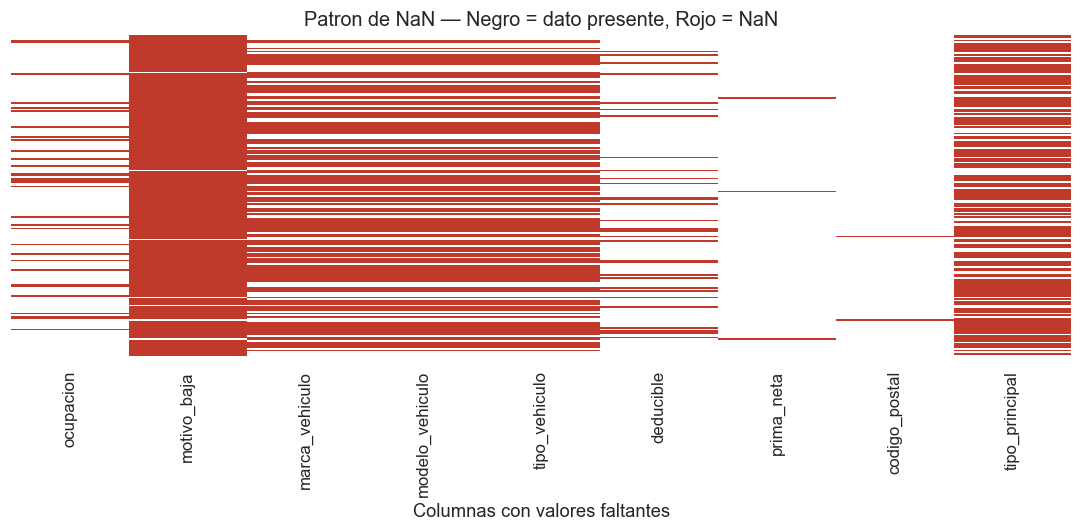

Correlacion entre columnas con NaN:
                 ocupacion  motivo_baja  marca_vehiculo  modelo_vehiculo  \
ocupacion            1.000        0.083           0.083            0.083   
motivo_baja          0.083        1.000           0.036            0.036   
marca_vehiculo       0.083        0.036           1.000            1.000   
modelo_vehiculo      0.083        0.036           1.000            1.000   
tipo_vehiculo        0.083        0.036           1.000            1.000   
deducible           -0.004       -0.065           0.313            0.313   
prima_neta          -0.054       -0.200           0.002            0.002   
codigo_postal       -0.044       -0.254          -0.034           -0.034   
tipo_principal      -0.022        0.058          -0.110           -0.110   

                 tipo_vehiculo  deducible  prima_neta  codigo_postal  \
ocupacion                0.083     -0.004      -0.054         -0.044   
motivo_baja              0.036     -0.065      -0.200      

In [91]:
# ── Visualizar patron de NaN ──────────────────────────────────────────────────
# Mapa de calor de NaN — ver si hay patrones entre columnas
cols_con_nan = [c for c in df_raw.columns if df_raw[c].isna().any()]
muestra = df_raw[cols_con_nan].sample(200, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    muestra.isna(),
    cbar=False,
    yticklabels=False,
    cmap=['white','#C0392B'],
    ax=ax
)
ax.set_title('Patron de NaN — Negro = dato presente, Rojo = NaN', fontsize=13)
ax.set_xlabel('Columnas con valores faltantes')
plt.tight_layout()
plt.show()

# Buscar si los NaN co-ocurren — si cuando falta A tambien falta B,
# probablemente son del mismo tipo o la misma fuente
print('Correlacion entre columnas con NaN:')
print(muestra.isna().corr().round(3))

---
## Bloque 2 — SimpleImputer: Imputacion Univariada

El imputer mas simple y el mas usado en produccion.
Calcula un estadistico de la columna y lo aplica a todos los NaN.

In [92]:
# ── Preparar subset numerico para imputar ────────────────────────────────────
# Trabajamos con prima_neta — tiene ~2% NaN (MCAR: error de captura)
features_num = ['prima_neta','suma_asegurada','edad','deducible']

# Solo GMM para el ejemplo (deducible tiene NaN en Vida por diseno)
df_gmm = df_raw[df_raw['ramo']=='GMM'][features_num].copy()
print(f'GMM: {df_gmm.shape}')
print('NaN:')
print(df_gmm.isna().sum())
print()

# Guardar los valores originales (los que NO son NaN) para comparar despues
prima_original = df_gmm['prima_neta'].dropna().copy()
print(f'Primas originales disponibles: {len(prima_original):,}')

GMM: (22531, 4)
NaN:
prima_neta        461
suma_asegurada      0
edad                0
deducible           0
dtype: int64

Primas originales disponibles: 22,070


In [93]:
# ── Las 4 estrategias de SimpleImputer ───────────────────────────────────────
estrategias = {
    'Media':    SimpleImputer(strategy='mean'),
    'Mediana':  SimpleImputer(strategy='median'),
    'Moda':     SimpleImputer(strategy='most_frequent'),
    'Constante':SimpleImputer(strategy='constant', fill_value=0),
}

resultados_imp = {}
for nombre, imp in estrategias.items():
    df_imp = pd.DataFrame(
        imp.fit_transform(df_gmm),
        columns=features_num
    )
    resultados_imp[nombre] = df_imp['prima_neta'].copy()
    val = imp.statistics_[features_num.index('prima_neta')]
    print(f'{nombre:<12}: imputa con ${val:,.2f}')

Media       : imputa con $26,900.09
Mediana     : imputa con $17,864.00
Moda        : imputa con $11,000.00
Constante   : imputa con $0.00


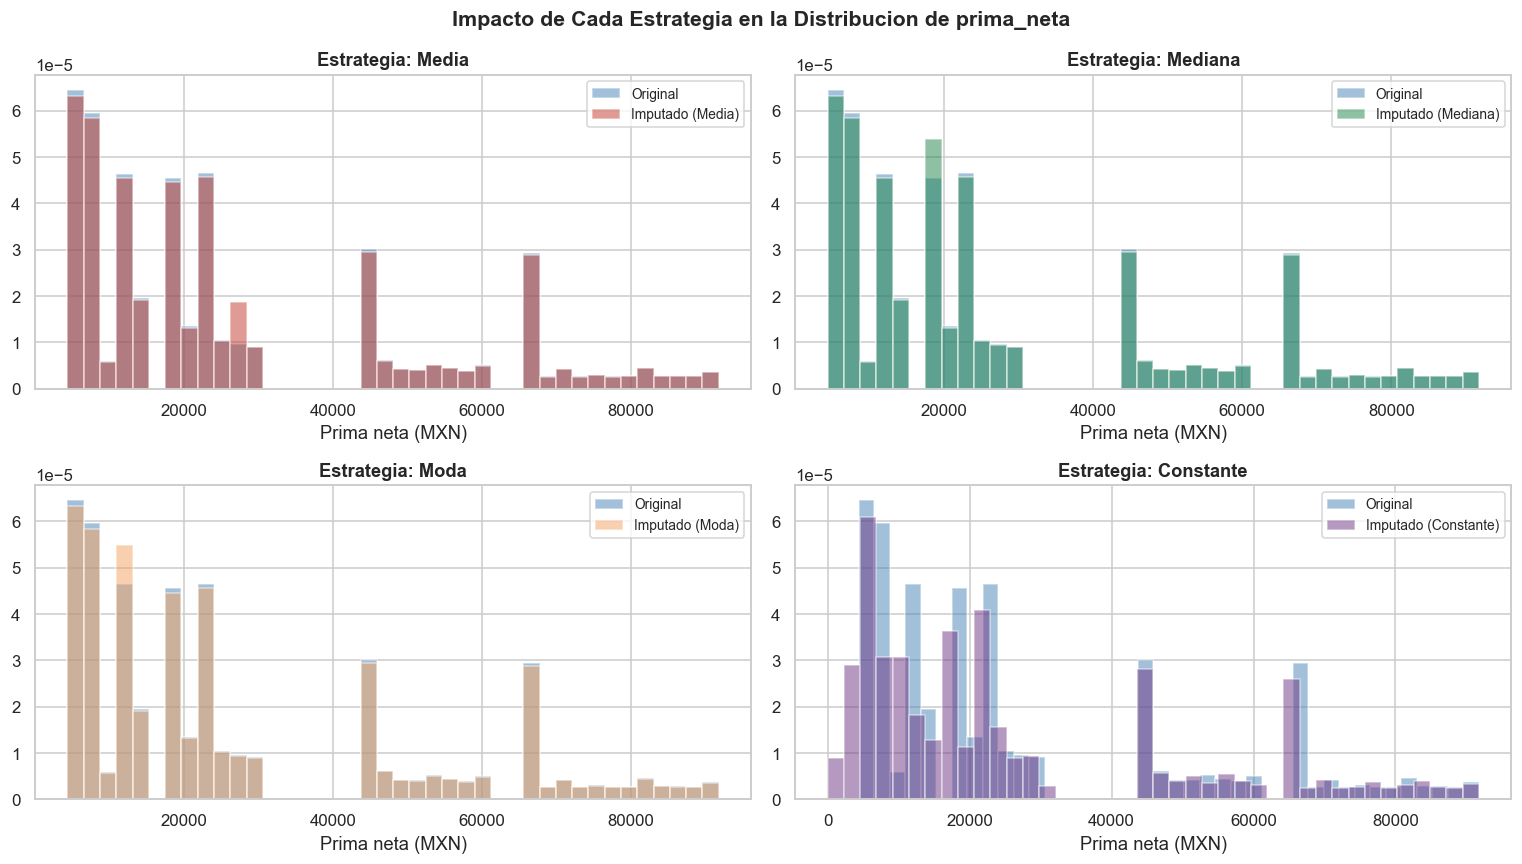

In [94]:
# ── Comparar las 4 estrategias visualmente ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colores = {'Media':'#C0392B','Mediana':'#1E8449','Moda':'#F4A261','Constante':'#6C3483'}

for ax, (nombre, serie) in zip(axes.flatten(), resultados_imp.items()):
    # Distribucion original (sin NaN)
    ax.hist(prima_original, bins=40, alpha=0.5,
            label='Original', color='steelblue', density=True)
    # Distribucion imputada
    ax.hist(serie, bins=40, alpha=0.5,
            label=f'Imputado ({nombre})', color=colores[nombre], density=True)
    ax.set_title(f'Estrategia: {nombre}', fontweight='bold')
    ax.set_xlabel('Prima neta (MXN)')
    ax.legend(fontsize=9)

fig.suptitle('Impacto de Cada Estrategia en la Distribucion de prima_neta',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# La estrategia CONSTANTE=0 es la que mas distorsiona — introduce un pico en 0
# Media y Mediana son similares aqui, pero con outliers la Mediana es mas robusta

### 📝 Ejercicio 1 — Comparar Estrategias (12 min)

**1a.** Para cada estrategia calcula: media, mediana y std de `prima_neta` despues de imputar.
Compara con los valores originales (sin NaN).

**1b.** Aplica el KS test (`stats.ks_2samp`) entre cada estrategia imputada y la distribucion original.
¿Cual tiene el p-value mas alto? (mayor p = mas similar a la original = mejor imputacion)

**1c.** ¿Que concluyes? ¿Cual estrategia recomendarias para `prima_neta` en esta cartera?

1a. Media, mediana y desviacion estandar despues de imputar


,estrategia,n,media,mediana,std,min,max,skew
0,Original sin NaN,22070,26900.09,17864.0,23446.20,4400.0,91740.0,1.10
1,Media,22531,26900.09,18128.0,23205.08,4400.0,91740.0,1.11
2,Mediana,22531,26715.21,17864.0,23240.32,4400.0,91740.0,1.13
3,Moda,22531,26574.77,17864.0,23314.01,4400.0,91740.0,1.13
4,Constante,22531,26349.70,17864.0,23515.51,0.0,91740.0,1.11


1b. KS test contra distribucion original sin NaN


,estrategia,KS,p_value
1,Mediana,0.010025,0.211001
2,Moda,0.013343,0.037425
0,Media,0.014059,0.024143
3,Constante,0.020461,0.000174



Mayor p-value: Mediana (p=0.211001)


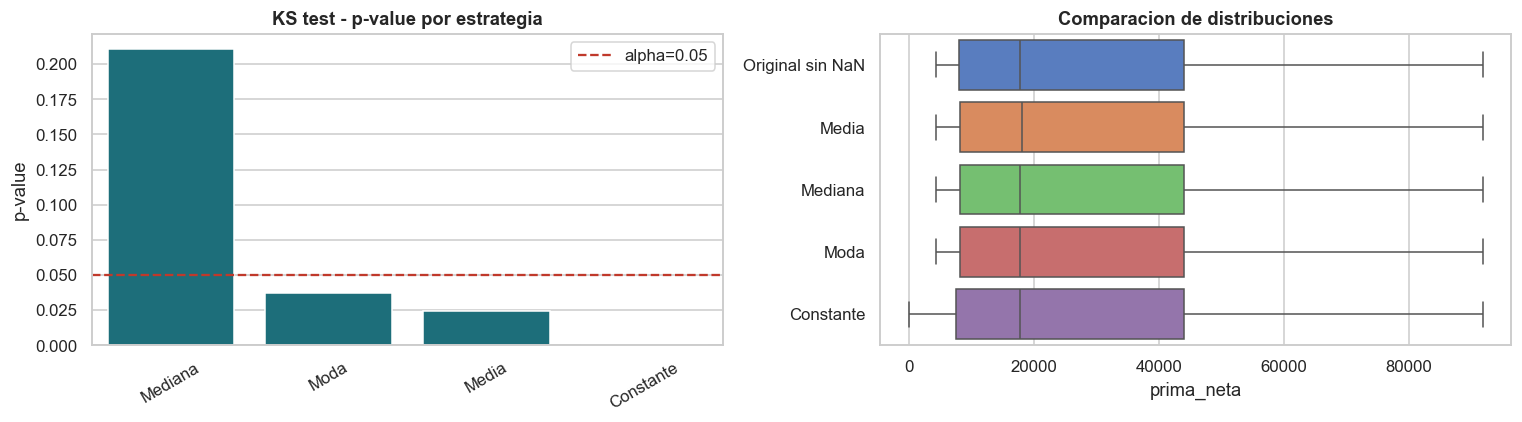

Conclusion:
La mejor estrategia es la que conserva mas parecida la distribucion original.
El p-value mas alto del KS test indica menor evidencia de distorsion distribucional.
Para prima_neta, al ser un NaN simulado como MCAR y de baja proporcion, media o mediana suelen comportarse bien; la constante 0 distorsiona mas la distribucion.


In [95]:
# Ejercicio 1 - Comparar estrategias univariadas

def resumen_serie_imputada(nombre, serie):
    serie = pd.Series(serie).dropna()
    return {
        'estrategia': nombre,
        'n': len(serie),
        'media': serie.mean(),
        'mediana': serie.median(),
        'std': serie.std(),
        'min': serie.min(),
        'max': serie.max(),
        'skew': serie.skew()
    }

resumen_ej1 = [resumen_serie_imputada('Original sin NaN', prima_original)]

ks_ej1 = []
for nombre, serie_imp in resultados_imp.items():
    resumen_ej1.append(resumen_serie_imputada(nombre, serie_imp))
    ks, p_value = stats.ks_2samp(prima_original, pd.Series(serie_imp).dropna())
    ks_ej1.append({
        'estrategia': nombre,
        'KS': ks,
        'p_value': p_value
    })

tabla_resumen_ej1 = pd.DataFrame(resumen_ej1)
tabla_ks_ej1 = pd.DataFrame(ks_ej1).sort_values('p_value', ascending=False)

print('1a. Media, mediana y desviacion estandar despues de imputar')
display(tabla_resumen_ej1.round(2))

print('1b. KS test contra distribucion original sin NaN')
display(tabla_ks_ej1.round(6))

mejor_ej1 = tabla_ks_ej1.iloc[0]
print()
print(f"Mayor p-value: {mejor_ej1['estrategia']} (p={mejor_ej1['p_value']:.6f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(
    data=tabla_ks_ej1,
    x='estrategia',
    y='p_value',
    ax=axes[0],
    color='#0D7A8A'
)
axes[0].axhline(0.05, color='#C0392B', linestyle='--', label='alpha=0.05')
axes[0].set_title('KS test - p-value por estrategia', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('p-value')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

plot_data = pd.DataFrame({'Original sin NaN': prima_original})
for nombre, serie_imp in resultados_imp.items():
    plot_data[nombre] = pd.Series(serie_imp).sample(
        n=len(plot_data),
        random_state=42,
        replace=False
    ).to_numpy()

sns.boxplot(data=plot_data, ax=axes[1], orient='h')
axes[1].set_title('Comparacion de distribuciones', fontweight='bold')
axes[1].set_xlabel('prima_neta')

plt.tight_layout()
plt.show()

print('Conclusion:')
print('La mejor estrategia es la que conserva mas parecida la distribucion original.')
print('El p-value mas alto del KS test indica menor evidencia de distorsion distribucional.')
print('Para prima_neta, al ser un NaN simulado como MCAR y de baja proporcion, media o mediana suelen comportarse bien; la constante 0 distorsiona mas la distribucion.')


---
## Bloque 3 — KNNImputer e IterativeImputer

Cuando el NaN es **MAR** (depende de otras variables),
los metodos univariados son insuficientes.
KNN y MICE usan el contexto de cada registro para estimar el valor faltante.

In [96]:
# ── Crear un dataset con NaN MAR para demostrar la diferencia ────────────────
# Simulamos que en polizas de mayor suma_asegurada hay mas NaN en prima_neta
# (patron MAR: el NaN depende de suma_asegurada)
np.random.seed(42)
df_demo = df_gmm.copy()

# Introducir NaN con patron MAR: mas NaN en sumas altas
prob_nan = (df_demo['suma_asegurada'] / df_demo['suma_asegurada'].max()) * 0.3
mask_nan = np.random.binomial(1, prob_nan.fillna(0)) == 1
df_demo.loc[mask_nan, 'prima_neta'] = np.nan

print(f'NaN introducidos con patron MAR: {mask_nan.sum()} ({mask_nan.mean():.1%})')
print('Verificar patron MAR:')
q33, q66 = df_demo['suma_asegurada'].quantile([0.33, 0.66])
for label, cond in [('Suma baja',df_demo['suma_asegurada']<=q33),
                    ('Suma media',(df_demo['suma_asegurada']>q33)&(df_demo['suma_asegurada']<=q66)),
                    ('Suma alta',df_demo['suma_asegurada']>q66)]:
    tasa = df_demo.loc[cond,'prima_neta'].isna().mean()
    print(f'  {label}: {tasa:.1%} NaN')
print('Si la tasa sube con la suma → es MAR')

NaN introducidos con patron MAR: 2487 (11.0%)
Verificar patron MAR:
  Suma baja: 5.2% NaN
  Suma media: 10.9% NaN
  Suma alta: 26.5% NaN
Si la tasa sube con la suma → es MAR


In [97]:
# ── KNNImputer — requiere normalizar primero ──────────────────────────────────
X_demo = df_demo[features_num].copy()

# Paso 1: normalizar (KNN es sensible a escala)
scaler = StandardScaler()
# Fit solo en filas sin NaN para no contaminar
X_sin_nan = X_demo.dropna()
scaler.fit(X_sin_nan)

# Transformar todo (con NaN — sklearn lo permite)
X_scaled = scaler.transform(X_demo)

# Paso 2: imputar en escala normalizada
imp_knn = KNNImputer(n_neighbors=5)
t0 = time.time()
X_knn = imp_knn.fit_transform(X_scaled)
t_knn = time.time()-t0

# Paso 3: regresar a escala original
X_knn_orig = scaler.inverse_transform(X_knn)
df_knn = pd.DataFrame(X_knn_orig, columns=features_num)

print(f'KNNImputer — tiempo: {t_knn:.2f}s')
print(f'NaN restantes: {df_knn.isna().sum().sum()}')

KNNImputer — tiempo: 3.08s
NaN restantes: 0


In [98]:
#  IterativeImputer (MICE) 
imp_mice = IterativeImputer(
    max_iter=10,
    random_state=42,
    initial_strategy='median'
)
t0 = time.time()
X_mice = imp_mice.fit_transform(X_demo)
t_mice = time.time()-t0

df_mice = pd.DataFrame(X_mice, columns=features_num)
print(f'IterativeImputer  tiempo: {t_mice:.2f}s')
print(f'NaN restantes: {df_mice.isna().sum().sum()}')
print()

#  Comparar los tres metodos donde introdujimos NaN artificial 
# df_gmm puede traer algunos NaN previos en prima_neta; para medir error
# solo usamos filas ocultadas por mask_nan y con valor real conocido.
idx_nan = pd.Series(np.asarray(mask_nan), name='idx_nan')
prima_verdadera = pd.Series(
    df_gmm.loc[df_demo.index, 'prima_neta'].to_numpy(),
    name='prima_verdadera'
)
idx_eval = idx_nan & prima_verdadera.notna()

prima_simple = pd.Series(
    SimpleImputer(strategy='median').fit_transform(X_demo)[:, features_num.index('prima_neta')],
    name='prima_simple'
)

print('Comparacion donde habia NaN artificial MAR:')
print(f'  NaN introducidos:        {idx_nan.sum():,}')
print(f'  Registros evaluables:   {idx_eval.sum():,}')
print(f'  Valor real promedio:     ${prima_verdadera[idx_eval].mean():,.2f}')
print(f'  SimpleImputer (mediana): ${prima_simple[idx_eval].mean():,.2f}')
print(f'  KNNImputer:              ${pd.Series(df_knn["prima_neta"].to_numpy())[idx_eval].mean():,.2f}')
print(f'  IterativeImputer:        ${pd.Series(df_mice["prima_neta"].to_numpy())[idx_eval].mean():,.2f}')
print()
print('Nota: con NaN MAR, KNN e IterativeImputer deberan acercarse mas')
print('al valor real que SimpleImputer porque usan el contexto de cada fila.')


IterativeImputer  tiempo: 0.05s
NaN restantes: 0

Comparacion donde habia NaN artificial MAR:
  NaN introducidos:        2,487
  Registros evaluables:   2,437
  Valor real promedio:     $46,573.24
  SimpleImputer (mediana): $17,600.00
  KNNImputer:              $46,882.63
  IterativeImputer:        $46,814.97

Nota: con NaN MAR, KNN e IterativeImputer deberan acercarse mas
al valor real que SimpleImputer porque usan el contexto de cada fila.


### 📝 Ejercicio 2 — KNN vs MICE (15 min)

**2a.** Para los registros donde introdujimos NaN artificialmente (variable `idx_nan`),
calcula el **Error Absoluto Medio (MAE)** entre el valor real y el valor imputado
por cada metodo: SimpleImputer, KNNImputer e IterativeImputer.

**2b.** Visualiza los tres metodos en un scatter:
eje X = valor real, eje Y = valor imputado.
El metodo perfecto tendria todos los puntos en la diagonal y=x.

**2c.** Prueba KNNImputer con k=3, k=5, k=10 y k=20.
¿Cual k da el menor MAE para este dataset?

**2d.** ¿En que situaciones de la cartera real usarias MICE en lugar de SimpleImputer?

Registros con NaN artificial: 2,487
Registros con valor real conocido: 2,437
Registros excluidos por NaN en real o imputacion: 0
Registros usados para MAE: 2,437

2a. MAE sobre registros con NaN artificial


,metodo,MAE
1,KNNImputer_k5,1395.11
2,IterativeImputer_MICE,3798.86
0,SimpleImputer_mediana,31085.86


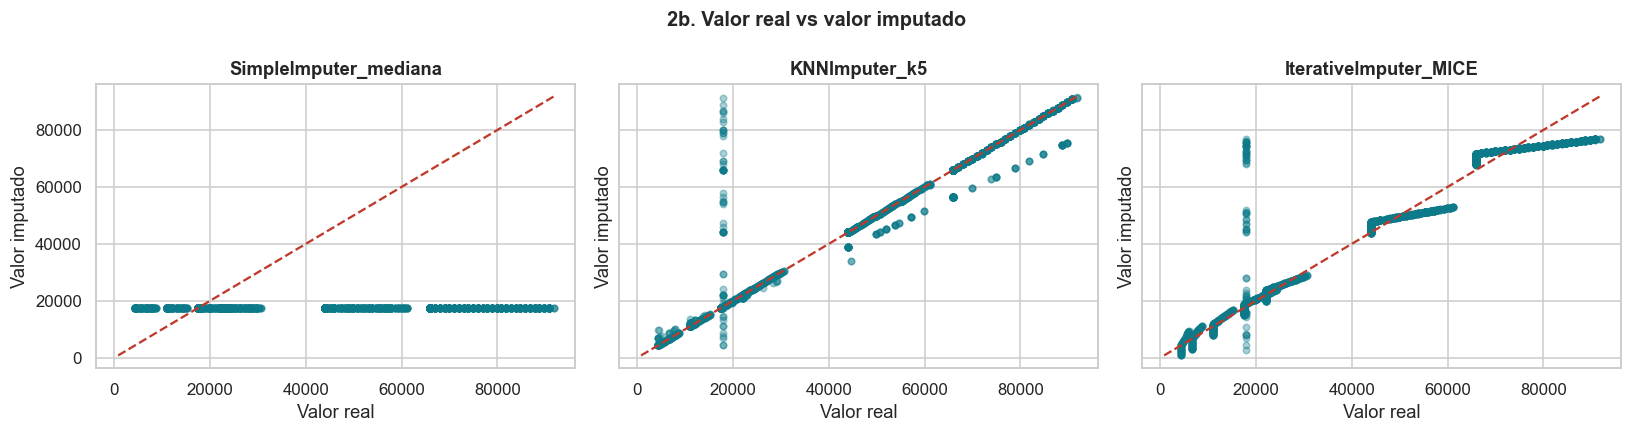

2c. Comparacion KNN con distintos k


,k,MAE,n_eval,tiempo_seg
1,5,1395.109,2437,3.140
2,10,1435.747,2437,3.099
3,20,1580.680,2437,3.028
0,3,1584.239,2437,3.104


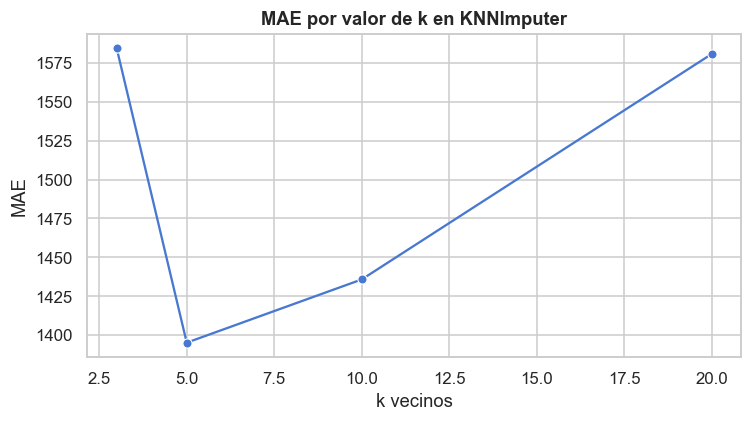

Conclusion:
El menor MAE se obtuvo con k=5, con MAE=1,395.11.
KNN y MICE aprovechan relaciones entre variables; por eso son mas apropiados cuando el patron es MAR.
El valor de k controla el balance entre imputaciones locales y suavizadas: k pequeno es mas sensible; k grande tiende a promediar mas.


In [99]:
# Ejercicio 2 - KNN vs MICE

# Alinear indices: df_gmm/df_demo conservan el indice original del parquet,
# mientras que df_knn/df_mice vienen de arreglos numpy con indice 0,1,2...
idx_nan_ej2 = pd.Series(np.asarray(mask_nan), name='idx_nan')
prima_real_ej2 = pd.Series(
    df_gmm.loc[df_demo.index, 'prima_neta'].to_numpy(),
    name='real'
)
idx_eval_ej2 = idx_nan_ej2 & prima_real_ej2.notna()

prima_simple_ej2 = pd.Series(
    SimpleImputer(strategy='median').fit_transform(X_demo)[:, features_num.index('prima_neta')],
    name='SimpleImputer_mediana'
)
prima_knn_ej2 = pd.Series(
    df_knn.reset_index(drop=True)['prima_neta'].to_numpy(),
    name='KNNImputer_k5'
)
prima_mice_ej2 = pd.Series(
    df_mice.reset_index(drop=True)['prima_neta'].to_numpy(),
    name='IterativeImputer_MICE'
)

comparacion_ej2 = pd.DataFrame({
    'real': prima_real_ej2[idx_eval_ej2].to_numpy(),
    'SimpleImputer_mediana': prima_simple_ej2[idx_eval_ej2].to_numpy(),
    'KNNImputer_k5': prima_knn_ej2[idx_eval_ej2].to_numpy(),
    'IterativeImputer_MICE': prima_mice_ej2[idx_eval_ej2].to_numpy()
})

comparacion_ej2 = comparacion_ej2.replace([np.inf, -np.inf], np.nan)
filas_con_nan_ej2 = comparacion_ej2.isna().any(axis=1).sum()
comparacion_ej2_valid = comparacion_ej2.dropna().reset_index(drop=True)

print(f'Registros con NaN artificial: {idx_nan_ej2.sum():,}')
print(f'Registros con valor real conocido: {idx_eval_ej2.sum():,}')
print(f'Registros excluidos por NaN en real o imputacion: {filas_con_nan_ej2:,}')
print(f'Registros usados para MAE: {len(comparacion_ej2_valid):,}')
print()

if comparacion_ej2_valid.empty:
    raise ValueError('No hay registros validos para calcular MAE despues de filtrar NaN.')

mae_ej2 = []
for col in ['SimpleImputer_mediana', 'KNNImputer_k5', 'IterativeImputer_MICE']:
    datos_validos = comparacion_ej2_valid[['real', col]].dropna()
    mae_ej2.append({
        'metodo': col,
        'MAE': mean_absolute_error(datos_validos['real'], datos_validos[col])
    })

tabla_mae_ej2 = pd.DataFrame(mae_ej2).sort_values('MAE')

print('2a. MAE sobre registros con NaN artificial')
display(tabla_mae_ej2.round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
metodos_scatter = ['SimpleImputer_mediana', 'KNNImputer_k5', 'IterativeImputer_MICE']

lim_min = comparacion_ej2_valid.min().min()
lim_max = comparacion_ej2_valid.max().max()

for ax, metodo in zip(axes, metodos_scatter):
    ax.scatter(
        comparacion_ej2_valid['real'],
        comparacion_ej2_valid[metodo],
        alpha=0.35,
        s=18,
        color='#0D7A8A'
    )
    ax.plot([lim_min, lim_max], [lim_min, lim_max], color='#C0392B', linestyle='--')
    ax.set_title(metodo, fontweight='bold')
    ax.set_xlabel('Valor real')
    ax.set_ylabel('Valor imputado')

fig.suptitle('2b. Valor real vs valor imputado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

k_values = [3, 5, 10, 20]
resultados_k = []
imputaciones_k = {}

for k in k_values:
    t0 = time.time()
    imp = KNNImputer(n_neighbors=k)
    X_knn_k = imp.fit_transform(X_scaled)
    X_knn_k_orig = scaler.inverse_transform(X_knn_k)
    df_knn_k = pd.DataFrame(X_knn_k_orig, columns=features_num).reset_index(drop=True)
    prima_knn_k = pd.Series(df_knn_k['prima_neta'].to_numpy())
    tiempo = time.time() - t0

    datos_k = pd.DataFrame({
        'real': prima_real_ej2[idx_eval_ej2].to_numpy(),
        'imputado': prima_knn_k[idx_eval_ej2].to_numpy()
    }).replace([np.inf, -np.inf], np.nan).dropna()

    mae = mean_absolute_error(datos_k['real'], datos_k['imputado'])
    resultados_k.append({
        'k': k,
        'MAE': mae,
        'n_eval': len(datos_k),
        'tiempo_seg': tiempo
    })
    imputaciones_k[k] = df_knn_k

tabla_k = pd.DataFrame(resultados_k).sort_values('MAE')

print('2c. Comparacion KNN con distintos k')
display(tabla_k.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(data=pd.DataFrame(resultados_k), x='k', y='MAE', marker='o', ax=ax)
ax.set_title('MAE por valor de k en KNNImputer', fontweight='bold')
ax.set_xlabel('k vecinos')
ax.set_ylabel('MAE')
plt.tight_layout()
plt.show()

mejor_k = tabla_k.iloc[0]
print('Conclusion:')
print(f"El menor MAE se obtuvo con k={int(mejor_k['k'])}, con MAE={mejor_k['MAE']:,.2f}.")
print('KNN y MICE aprovechan relaciones entre variables; por eso son mas apropiados cuando el patron es MAR.')
print('El valor de k controla el balance entre imputaciones locales y suavizadas: k pequeno es mas sensible; k grande tiende a promediar mas.')


---
## Bloque 4 — Evaluar el Impacto


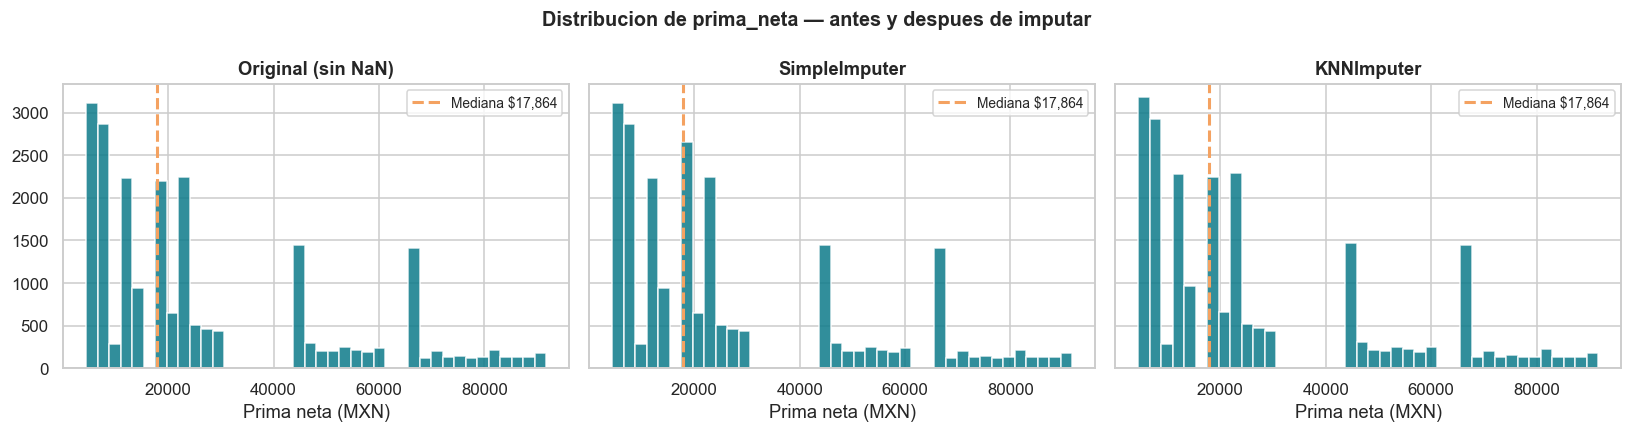

In [100]:
# ── Comparar distribuciones antes y despues ──────────────────────────────────
# Dataset completo — comparar SimpleImputer vs KNNImputer

df_trabajo = df_raw[df_raw['ramo']=='GMM'][features_num].copy()
prima_original_full = df_trabajo['prima_neta'].dropna()

# SimpleImputer con mediana
df_simple = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(df_trabajo),
    columns=features_num
)

# KNNImputer
scaler2 = StandardScaler()
X_sc2 = scaler2.fit_transform(df_trabajo)
X_knn2 = KNNImputer(n_neighbors=5).fit_transform(X_sc2)
df_knn2 = pd.DataFrame(scaler2.inverse_transform(X_knn2), columns=features_num)

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (nombre, serie) in zip(axes, [
    ('Original (sin NaN)', prima_original_full),
    ('SimpleImputer',      df_simple['prima_neta']),
    ('KNNImputer',         df_knn2['prima_neta']),
]):
    ax.hist(serie, bins=40, color='#0D7A8A', edgecolor='white', alpha=0.85)
    ax.axvline(serie.median(), color='#F4A261', linewidth=2,
               linestyle='--', label=f'Mediana ${serie.median():,.0f}')
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('Prima neta (MXN)')
    ax.legend(fontsize=9)

fig.suptitle('Distribucion de prima_neta — antes y despues de imputar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [101]:
# ── KS Test formal ───────────────────────────────────────────────────────────
for nombre, serie in [('SimpleImputer', df_simple['prima_neta']),
                      ('KNNImputer',    df_knn2['prima_neta'])]:
    ks, pv = stats.ks_2samp(prima_original_full, serie)
    print(f'{nombre:<18}: KS={ks:.4f}  p={pv:.4f}  '","
          f"{'OK - no distorsiona' if pv>0.05 else 'DISTORSIONA la distribucion'}")
print()
print('p > 0.05 significa que la imputacion no distorsiona significativamente')

SimpleImputer     : KS=0.0100  p=0.2110  ,OK - no distorsiona
KNNImputer        : KS=0.0037  p=0.9980  ,OK - no distorsiona

p > 0.05 significa que la imputacion no distorsiona significativamente


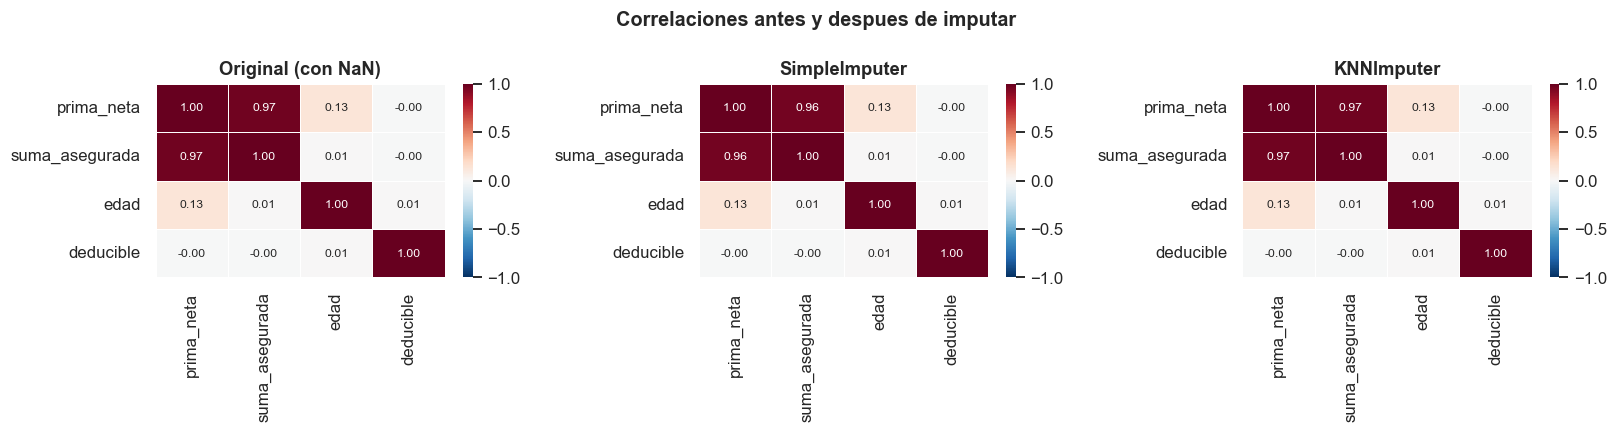

Diferencia maxima en correlaciones: 0.0111


In [102]:
# ── Comparar correlaciones antes y despues ───────────────────────────────────
corr_original = df_trabajo.corr(numeric_only=True)
corr_simple   = df_simple.corr(numeric_only=True)
corr_knn      = df_knn2.corr(numeric_only=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kws = dict(annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
           linewidths=0.5, annot_kws={'size':8})

sns.heatmap(corr_original, ax=axes[0], **kws)
axes[0].set_title('Original (con NaN)', fontweight='bold')
sns.heatmap(corr_simple, ax=axes[1], **kws)
axes[1].set_title('SimpleImputer', fontweight='bold')
sns.heatmap(corr_knn, ax=axes[2], **kws)
axes[2].set_title('KNNImputer', fontweight='bold')

fig.suptitle('Correlaciones antes y despues de imputar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

diff = (corr_simple - corr_knn).abs()
print(f'Diferencia maxima en correlaciones: {diff.max().max():.4f}')

---
## Ejercicio Integrador — Pipeline Completo de Imputacion

Construye el pipeline de imputacion completo para preparar la cartera
para un modelo predictivo. Cada decision debe estar justificada.

### Las 4 Fases

**Fase 1 — Diagnostico**
Para cada columna con NaN, determina si es MCAR, MAR o MNAR.
Justifica con datos — no intuicion.

**Fase 2 — Estrategia por columna**
Diseña la estrategia de imputacion para cada columna.
No todas las columnas necesitan el mismo metodo.

**Fase 3 — Implementar y evaluar**
Aplica las estrategias. Para las columnas numericas clave,
verifica con KS test que la distribucion no se distorsiona.

**Fase 4 — Impacto en el modelo**
Entrena tres Pipelines sklearn (SimpleImputer, KNNImputer, IterativeImputer)
con LinearRegression para predecir `prima_total`.
Compara R2 y MAE. ¿Que metodo de imputacion da el mejor modelo?

In [103]:
# FASE 1 - Diagnostico

df_gmm_full = df_raw[df_raw['ramo'] == 'GMM'].copy()

if 'g_edad_tmp' not in df_gmm_full.columns:
    df_gmm_full['g_edad_tmp'] = pd.cut(
        df_gmm_full['edad'],
        bins=[0, 30, 45, 60, 120],
        labels=['<=30', '31-45', '46-60', '61+']
    )

cols_nan_gmm = [
    col for col in df_gmm_full.columns
    if df_gmm_full[col].isna().any() and col != 'g_edad_tmp'
]

print(f"Filas en GMM: {len(df_gmm_full):,}")
print()
print("Columnas con NaN en GMM:")
display(df_gmm_full[cols_nan_gmm].isna().sum().to_frame('n_nan'))
print()

diagnostico_gmm = []

if 'prima_neta' in df_gmm_full.columns:
    diagnostico_gmm.append({
        'columna': 'prima_neta',
        'pct_nan': df_gmm_full['prima_neta'].isna().mean(),
        'mecanismo': 'MCAR probable',
        'evidencia': 'NaN de baja proporcion, introducido como error aleatorio en el ejercicio.'
    })

if 'deducible' in df_gmm_full.columns:
    diagnostico_gmm.append({
        'columna': 'deducible',
        'pct_nan': df_gmm_full['deducible'].isna().mean(),
        'mecanismo': 'MCAR residual en GMM',
        'evidencia': 'En GMM el deducible si aplica; no se debe tratar como No aplica.'
    })

if 'ocupacion' in df_gmm_full.columns:
    tasas_ocupacion = (
        df_gmm_full
        .groupby('g_edad_tmp', observed=True)['ocupacion']
        .apply(lambda s: s.isna().mean())
    )
    diagnostico_gmm.append({
        'columna': 'ocupacion',
        'pct_nan': df_gmm_full['ocupacion'].isna().mean(),
        'mecanismo': 'MAR',
        'evidencia': 'La tasa de NaN cambia por grupo de edad.'
    })

diagnostico_nan_gmm = pd.DataFrame(diagnostico_gmm)

print("Diagnostico resumido:")
display(diagnostico_nan_gmm.round(4))

if 'ocupacion' in df_gmm_full.columns:
    print("Tasa de NaN en ocupacion por grupo de edad:")
    display(tasas_ocupacion.round(4).to_frame('tasa_nan'))

print("Conclusion Fase 1:")
print("Dentro de GMM, prima_neta y deducible pueden tratarse con metodos simples de imputacion numerica. ocupacion muestra un patron relacionado con edad, por lo que conviene imputarla por grupo de edad.")


Filas en GMM: 22,531

Columnas con NaN en GMM:


,n_nan
ocupacion,3865
motivo_baja,21448
marca_vehiculo,22531
modelo_vehiculo,22531
tipo_vehiculo,22531
prima_neta,461
codigo_postal,690
tipo_principal,15686



Diagnostico resumido:


,columna,pct_nan,mecanismo,evidencia
0,prima_neta,0.0205,MCAR probable,"NaN de baja proporcion, introducido como error..."
1,deducible,0.0000,MCAR residual en GMM,En GMM el deducible si aplica; no se debe trat...
2,ocupacion,0.1715,MAR,La tasa de NaN cambia por grupo de edad.


Tasa de NaN en ocupacion por grupo de edad:


,tasa_nan
g_edad_tmp,
18-30,0.1039
31-45,0.1520
46-60,0.2089
61+,0.2447


Conclusion Fase 1:
Dentro de GMM, prima_neta y deducible pueden tratarse con metodos simples de imputacion numerica. ocupacion muestra un patron relacionado con edad, por lo que conviene imputarla por grupo de edad.


In [104]:
# FASE 2 - Estrategia por columna

estrategia_columnas = []

for col in cols_nan_gmm:
    if col == 'prima_neta':
        estrategia = 'SimpleImputer con mediana'
        justificacion = 'Variable numerica con pocos NaN; la mediana es robusta ante valores extremos.'
    elif col == 'deducible':
        estrategia = 'SimpleImputer con mediana'
        justificacion = 'En GMM el deducible si existe; se imputa como faltante numerico, no como cero estructural.'
    elif col == 'ocupacion':
        estrategia = 'Moda por grupo de edad'
        justificacion = 'El faltante depende de edad, por eso se usa una moda segmentada.'
    elif pd.api.types.is_numeric_dtype(df_gmm_full[col]):
        estrategia = 'SimpleImputer con mediana'
        justificacion = 'Estrategia simple para variables numericas.'
    else:
        estrategia = 'Moda global / No informado'
        justificacion = 'Estrategia simple para variables categoricas.'

    estrategia_columnas.append({
        'columna': col,
        'estrategia': estrategia,
        'justificacion': justificacion
    })

estrategia_nan_gmm = pd.DataFrame(estrategia_columnas)

print("Fase 2 - Estrategia propuesta:")
display(estrategia_nan_gmm)

print("Conclusion Fase 2:")
print("La estrategia se mantiene simple: mediana para numericas y moda para categoricas. Solo ocupacion se segmenta por edad porque su faltante tiene patron MAR.")


Fase 2 - Estrategia propuesta:


,columna,estrategia,justificacion
0,ocupacion,Moda por grupo de edad,"El faltante depende de edad, por eso se usa un..."
1,motivo_baja,Moda global / No informado,Estrategia simple para variables categoricas.
2,marca_vehiculo,Moda global / No informado,Estrategia simple para variables categoricas.
3,modelo_vehiculo,SimpleImputer con mediana,Estrategia simple para variables numericas.
4,tipo_vehiculo,Moda global / No informado,Estrategia simple para variables categoricas.
5,prima_neta,SimpleImputer con mediana,Variable numerica con pocos NaN; la mediana es...
6,codigo_postal,SimpleImputer con mediana,Estrategia simple para variables numericas.
7,tipo_principal,Moda global / No informado,Estrategia simple para variables categoricas.


Conclusion Fase 2:
La estrategia se mantiene simple: mediana para numericas y moda para categoricas. Solo ocupacion se segmenta por edad porque su faltante tiene patron MAR.


NaN antes y despues de imputar:


,nan_antes,nan_despues,resueltos
ocupacion,3865,0,3865
motivo_baja,21448,0,21448
marca_vehiculo,22531,0,22531
modelo_vehiculo,22531,0,22531
tipo_vehiculo,22531,0,22531
prima_neta,461,0,461
codigo_postal,690,0,690
tipo_principal,15686,0,15686


KS test para variables numericas clave:


,columna,KS,p_value,media_original,media_imputada,mediana_original,mediana_imputada
0,prima_neta,0.01,0.211,26900.0928,26715.2080,17864.0,17864.0
1,deducible,0.00,1.000,11623.5409,11623.5409,10000.0,10000.0


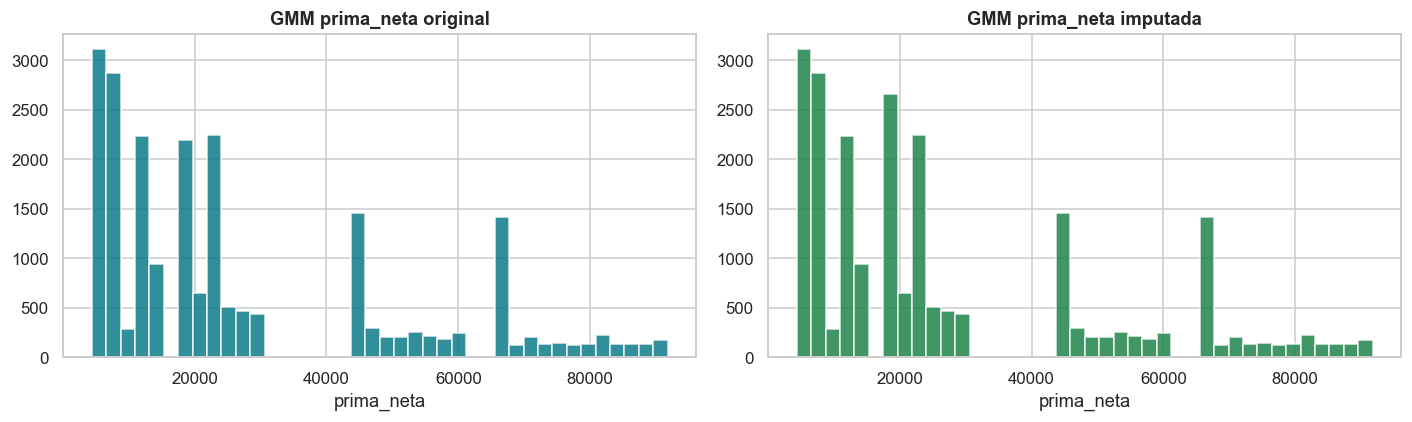

Conclusion Fase 3:
La imputacion elimina los NaN de las columnas revisadas. El KS test permite confirmar si la distribucion de prima_neta y deducible se mantiene razonablemente estable despues de imputar.


In [105]:
# FASE 3 - Implementar y evaluar

df_clean_gmm = df_gmm_full.copy()
nan_antes_gmm = df_clean_gmm[cols_nan_gmm].isna().sum()

if 'prima_neta' in cols_nan_gmm:
    df_clean_gmm['prima_neta'] = SimpleImputer(strategy='median').fit_transform(
        df_clean_gmm[['prima_neta']]
    ).ravel()

if 'deducible' in cols_nan_gmm:
    if df_clean_gmm['deducible'].notna().any():
        df_clean_gmm['deducible'] = SimpleImputer(strategy='median').fit_transform(
            df_clean_gmm[['deducible']]
        ).ravel()
    else:
        df_clean_gmm['deducible'] = 0

if 'ocupacion' in cols_nan_gmm:
    df_clean_gmm['ocupacion'] = df_clean_gmm.groupby('g_edad_tmp', observed=True)['ocupacion'].transform(
        lambda s: s.fillna(s.mode().iloc[0]) if not s.mode(dropna=True).empty else s
    )
    df_clean_gmm['ocupacion'] = df_clean_gmm['ocupacion'].fillna('No informado')

for col in cols_nan_gmm:
    if col in ['prima_neta', 'deducible', 'ocupacion']:
        continue
    if pd.api.types.is_numeric_dtype(df_clean_gmm[col]):
        if df_clean_gmm[col].notna().any():
            df_clean_gmm[col] = SimpleImputer(strategy='median').fit_transform(
                df_clean_gmm[[col]]
            ).ravel()
        else:
            df_clean_gmm[col] = 0
    else:
        moda = df_clean_gmm[col].mode(dropna=True)
        relleno = moda.iloc[0] if not moda.empty else 'No informado'
        df_clean_gmm[col] = df_clean_gmm[col].astype('object').fillna(relleno)

nan_despues_gmm = df_clean_gmm[cols_nan_gmm].isna().sum()

auditoria_imputacion_gmm = pd.DataFrame({
    'nan_antes': nan_antes_gmm,
    'nan_despues': nan_despues_gmm
})
auditoria_imputacion_gmm['resueltos'] = (
    auditoria_imputacion_gmm['nan_antes'] - auditoria_imputacion_gmm['nan_despues']
)

print("NaN antes y despues de imputar:")
display(auditoria_imputacion_gmm)

evaluacion_dist_gmm = []

for col in ['prima_neta', 'deducible']:
    if col in df_gmm_full.columns:
        original = df_gmm_full[col].dropna()
        imputada = df_clean_gmm[col].dropna()
        if len(original) > 0 and len(imputada) > 0:
            ks, p_value = stats.ks_2samp(original, imputada)
            evaluacion_dist_gmm.append({
                'columna': col,
                'KS': ks,
                'p_value': p_value,
                'media_original': original.mean(),
                'media_imputada': imputada.mean(),
                'mediana_original': original.median(),
                'mediana_imputada': imputada.median()
            })

tabla_eval_dist_gmm = pd.DataFrame(evaluacion_dist_gmm)

print("KS test para variables numericas clave:")
display(tabla_eval_dist_gmm.round(4))

if 'prima_neta' in df_gmm_full.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    df_gmm_full['prima_neta'].dropna().hist(bins=40, ax=axes[0], color='#0D7A8A', alpha=0.85)
    axes[0].set_title('GMM prima_neta original', fontweight='bold')
    axes[0].set_xlabel('prima_neta')

    df_clean_gmm['prima_neta'].hist(bins=40, ax=axes[1], color='#1E8449', alpha=0.85)
    axes[1].set_title('GMM prima_neta imputada', fontweight='bold')
    axes[1].set_xlabel('prima_neta')

    plt.tight_layout()
    plt.show()

print("Conclusion Fase 3:")
print("La imputacion elimina los NaN de las columnas revisadas. El KS test permite confirmar si la distribucion de prima_neta y deducible se mantiene razonablemente estable despues de imputar.")


NaN en las features del modelo:


,n_nan
edad,0
suma_asegurada,0
deducible,0
n_siniestros,0



Comparacion de pipelines:


,pipeline,R2,MAE,tiempo_seg
0,SimpleImputer_mediana,0.9829,2720.1438,0.0069
1,KNNImputer_k5,0.9829,2720.1438,0.0036
2,IterativeImputer_MICE,0.9829,2720.1438,0.0212


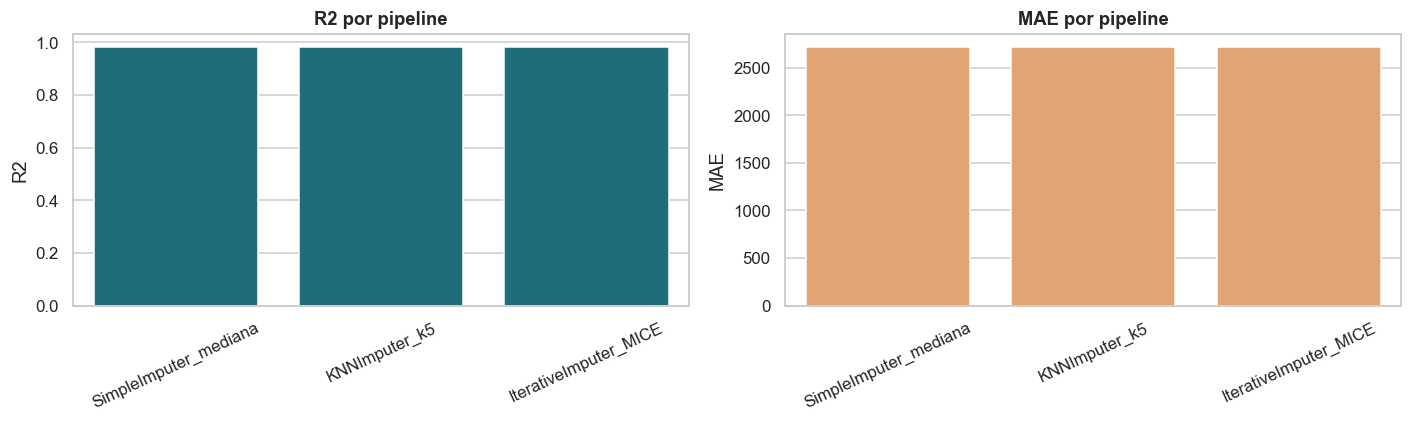

Conclusion Fase 4:
El mejor pipeline por MAE fue SimpleImputer_mediana, con MAE=2,720.14 y R2=0.9829.
Si los resultados son muy parecidos, conviene preferir SimpleImputer por ser mas simple, rapido y facil de explicar.


In [ ]:
# FASE 4 - Impacto en el modelo

import time

features_modelo = [
    col for col in ['edad', 'suma_asegurada', 'deducible', 'n_siniestros']
    if col in df_gmm_full.columns
]

df_modelo_gmm = df_gmm_full[features_modelo + ['prima_total']].dropna(subset=['prima_total']).copy()

X = df_modelo_gmm[features_modelo]
y = df_modelo_gmm['prima_total']

print("NaN en las features del modelo:")
display(X.isna().sum().to_frame('n_nan'))
print()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

pipelines = {
    'SimpleImputer_mediana': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('modelo', LinearRegression())
    ]),
    'KNNImputer_k5': Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler', StandardScaler()),
        ('modelo', LinearRegression())
    ]),
    'IterativeImputer_MICE': Pipeline([
        ('imputer', IterativeImputer(max_iter=10, random_state=42, initial_strategy='median')),
        ('scaler', StandardScaler()),
        ('modelo', LinearRegression())
    ])
}

resultados_modelo_gmm = []

for nombre, pipe in pipelines.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    tiempo = time.time() - t0
    pred = pipe.predict(X_test)

    resultados_modelo_gmm.append({
        'pipeline': nombre,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'tiempo_seg': tiempo
    })

tabla_modelos_gmm = pd.DataFrame(resultados_modelo_gmm).sort_values('MAE')

print("Comparacion de pipelines:")
display(tabla_modelos_gmm.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=tabla_modelos_gmm, x='pipeline', y='R2', ax=axes[0], color='#0D7A8A')
axes[0].set_title('R2 por pipeline', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=tabla_modelos_gmm, x='pipeline', y='MAE', ax=axes[1], color='#F4A261')
axes[1].set_title('MAE por pipeline', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

mejor_modelo_gmm = tabla_modelos_gmm.iloc[0]

print("Conclusion Fase 4:")
print(f"El mejor pipeline por MAE fue {mejor_modelo_gmm['pipeline']}, con MAE={mejor_modelo_gmm['MAE']:,.2f} y R2={mejor_modelo_gmm['R2']:.4f}.")


---
## Resumen

| Metodo | Cuando usarlo | Ventaja | Limitacion |
|--------|--------------|---------|------------|
| **SimpleImputer** | MCAR, pocas filas afectadas | Rapido, reproducible | Ignora relaciones entre variables |
| **KNNImputer** | MAR, variables correlacionadas | Usa contexto local | Lento, sensible a escala |
| **IterativeImputer** | MAR, muchas variables correlacionadas | Gold standard estadistico | Mas lento, requiere ajuste |

**Regla de oro:** fit() solo en datos de entrenamiento. Nunca en test.